# PoC-2 · Engram Neural Network (ENN) — memoria Hebbiana entrenable
### Proyecto EMBER (Emergent Memory-Based Encoding and Reactivation)

Segunda de ocho pruebas de concepto. Valida la otra mitad de la **Hipótesis 2** del documento de trabajo: que una memoria Hebbiana explícita y entrenable se comporta como predice la literatura — entrenamiento estable, trazas que se fortalecen con la repetición, y trazas que decaen cuando dejan de reforzarse.

**Nota sobre la implementación:** el paper de referencia (Szelogowski, 2025, *Hebbian Memory-Augmented Recurrent Networks*) publica su código como el paquete `tensorflow-engram`. Acá se reimplementa el mismo mecanismo conceptual — pesos lentos (encoder, entrenado por backprop) + pesos rápidos Hebbianos (la memoria tipo engrama, actualizada por una regla de refuerzo/decaimiento, no por gradiente) — en PyTorch, para mantener consistencia con el resto del proyecto.

## 1. Idea central de una ENN

Una Engram Neural Network combina dos tipos de pesos:

- **Pesos sinápticos (lentos):** los de un encoder normal, entrenados por backpropagation. Cambian poco a poco, igual que cualquier red neuronal.
- **Pesos de engrama (rápidos):** una matriz de memoria explícita, una fila por clase/concepto, que **no se entrena por gradiente**. Se actualiza con una regla Hebbiana: se refuerza cuando la clase aparece (la traza "se enciende junto con" el embedding que la activó) y decae con el tiempo si no se refuerza — igual que un engrama biológico que se debilita sin reactivación.

La clasificación final no usa una capa lineal entrenada aparte: se lee directamente comparando el embedding actual contra cada traza de la memoria (similitud). La memoria *es* el clasificador.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class HebbianEngramMemory(nn.Module):
    """
    Memoria tipo engrama: una traza Hebbiana explicita por clase (no entrenada por
    backprop, sino actualizada con una regla Hebbiana de refuerzo + decaimiento).
    """

    def __init__(self, n_classes, embedding_dim, decay=0.95, eta=0.5):
        super().__init__()
        self.decay = decay
        self.eta = eta
        self.register_buffer("engrams", torch.zeros(n_classes, embedding_dim))

    def read(self, emb):
        return emb @ self.engrams.t()  # similitud embedding-traza

    @torch.no_grad()
    def reinforce(self, emb, y):
        self.engrams.mul_(self.decay)  # decaimiento global
        emb_detached = emb.detach()
        for cls in y.unique():
            mask = y == cls
            mean_emb = emb_detached[mask].mean(dim=0)
            self.engrams[cls] += self.eta * mean_emb  # refuerzo Hebbiano

    def trace_norms(self):
        return self.engrams.norm(dim=1).detach().cpu().numpy()


class EngramNeuralNetwork(nn.Module):
    """Encoder entrenable (pesos lentos) + memoria Hebbiana explicita (pesos rapidos)."""

    def __init__(self, input_dim, hidden_dim, embedding_dim, n_classes, decay=0.95, eta=0.5):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embedding_dim),
        )
        self.memory = HebbianEngramMemory(n_classes, embedding_dim, decay=decay, eta=eta)

    def forward(self, x):
        emb = self.encoder(x)
        emb = F.normalize(emb, dim=1)
        logits = self.memory.read(emb)
        return logits, emb


print("EngramNeuralNetwork lista.")

EngramNeuralNetwork lista.


## 2. Tarea sintética y diseño del experimento

5 clases, cada una con un prototipo aleatorio fijo en `R^64`; las muestras son ese prototipo más ruido gaussiano (mismo espíritu que la PoC-1, para que los resultados sean comparables).

El experimento tiene dos fases:

1. **Fase 1 (60 épocas):** las 5 clases aparecen normalmente. Se espera que el entrenamiento converja y que las 5 trazas crezcan de forma pareja.
2. **Fase 2 (40 épocas):** la clase 0 deja de aparecer por completo. Se espera que su traza decaiga (sin refuerzo) mientras las otras 4 sigan creciendo.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
np.random.seed(0)

N_CLASSES, INPUT_DIM, HIDDEN_DIM, EMB_DIM = 5, 64, 64, 16
N_PER_CLASS, NOISE_STD = 40, 0.6
EPOCHS_PHASE1, EPOCHS_PHASE2 = 60, 40

prototypes = torch.randn(N_CLASSES, INPUT_DIM)


def sample_batch(classes, n_per_class):
    xs, ys = [], []
    for c in classes:
        x = prototypes[c].unsqueeze(0) + NOISE_STD * torch.randn(n_per_class, INPUT_DIM)
        xs.append(x)
        ys.append(torch.full((n_per_class,), c, dtype=torch.long))
    return torch.cat(xs), torch.cat(ys)


model = EngramNeuralNetwork(INPUT_DIM, HIDDEN_DIM, EMB_DIM, N_CLASSES, decay=0.97, eta=0.6)
optimizer = torch.optim.Adam(model.encoder.parameters(), lr=1e-3)

loss_history, acc_history, trace_norms_history = [], [], []


def run_epoch(active_classes):
    x, y = sample_batch(active_classes, N_PER_CLASS)
    perm = torch.randperm(x.shape[0])
    x, y = x[perm], y[perm]
    optimizer.zero_grad()
    logits, emb = model(x)
    loss = F.cross_entropy(logits, y)
    loss.backward()
    optimizer.step()
    with torch.no_grad():
        _, emb_for_memory = model(x)
    model.memory.reinforce(emb_for_memory, y)
    acc = (logits.argmax(dim=1) == y).float().mean().item()
    return loss.item(), acc


print("--- Fase 1: las 5 clases activas ---")
for epoch in range(EPOCHS_PHASE1):
    loss, acc = run_epoch(list(range(N_CLASSES)))
    loss_history.append(loss)
    acc_history.append(acc)
    trace_norms_history.append(model.memory.trace_norms())
    if epoch % 10 == 0 or epoch == EPOCHS_PHASE1 - 1:
        print(
            f"epoch {epoch:3d}  loss={loss:.3f}  acc={acc:.3f}  norma trazas={np.round(model.memory.trace_norms(), 2)}"
        )

print("\n--- Fase 2: la clase 0 deja de aparecer ---")
for epoch in range(EPOCHS_PHASE2):
    loss, acc = run_epoch(list(range(1, N_CLASSES)))
    loss_history.append(loss)
    acc_history.append(acc)
    trace_norms_history.append(model.memory.trace_norms())
    if epoch % 10 == 0 or epoch == EPOCHS_PHASE2 - 1:
        print(
            f"epoch {epoch:3d}  loss={loss:.3f}  acc={acc:.3f}  norma trazas={np.round(model.memory.trace_norms(), 2)}"
        )

trace_norms_history = np.array(trace_norms_history)

--- Fase 1: las 5 clases activas ---
epoch   0  loss=1.609  acc=0.200  norma trazas=[0.54 0.56 0.39 0.54 0.52]
epoch  10  loss=0.072  acc=1.000  norma trazas=[5.05 5.1  4.47 4.98 4.83]
epoch  20  loss=0.001  acc=1.000  norma trazas=[8.48 8.24 8.07 8.24 8.35]
epoch  30  loss=0.000  acc=1.000  norma trazas=[11.18 10.85 10.88 10.88 11.1 ]
epoch  40  loss=0.000  acc=1.000  norma trazas=[13.25 12.92 13.02 12.95 13.2 ]
epoch  50  loss=0.000  acc=1.000  norma trazas=[14.82 14.52 14.62 14.51 14.77]
epoch  59  loss=0.000  acc=1.000  norma trazas=[15.89 15.61 15.71 15.59 15.85]

--- Fase 2: la clase 0 deja de aparecer ---
epoch   0  loss=0.000  acc=1.000  norma trazas=[15.42 15.71 15.82 15.7  15.96]
epoch  10  loss=0.000  acc=1.000  norma trazas=[11.37 16.63 16.71 16.58 16.84]
epoch  20  loss=0.000  acc=1.000  norma trazas=[ 8.38 17.3  17.37 17.24 17.49]
epoch  30  loss=0.000  acc=1.000  norma trazas=[ 6.18 17.79 17.85 17.74 17.97]
epoch  39  loss=0.000  acc=1.000  norma trazas=[ 4.7  18.13 18.1

## 3. Resultado 1 — Estabilidad del entrenamiento

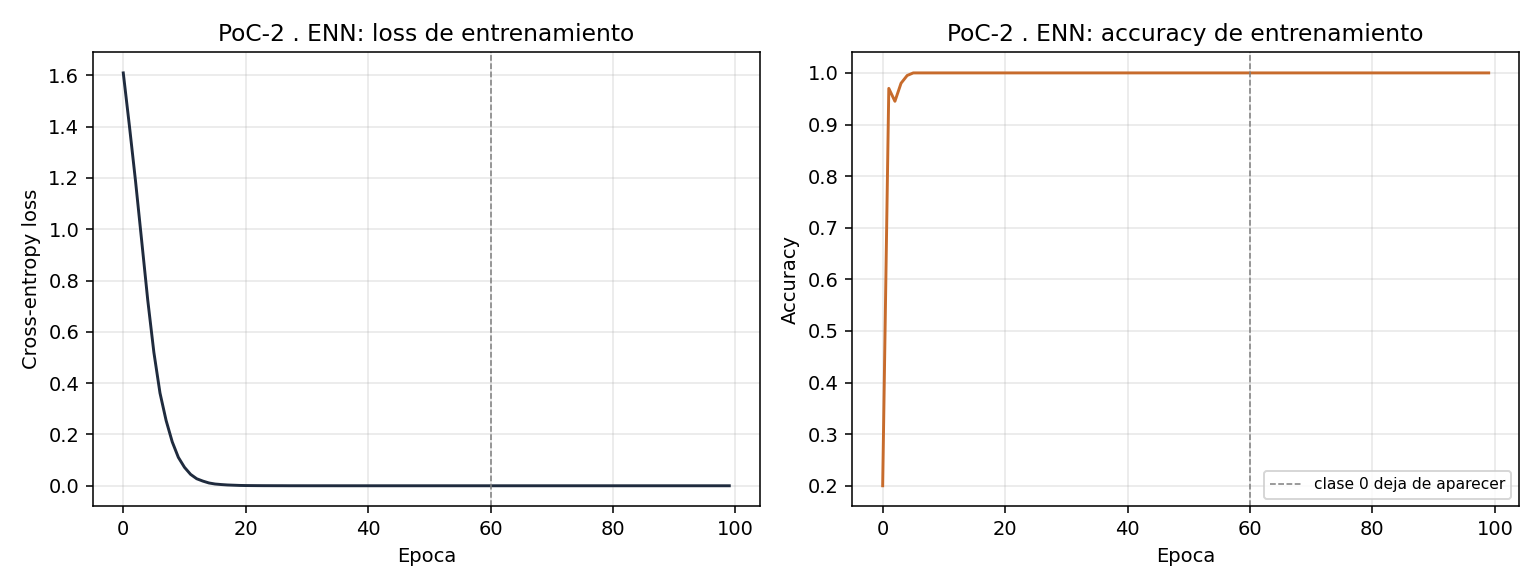

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(loss_history, color="#1F2B3E")
axes[0].axvline(EPOCHS_PHASE1, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("PoC-2 . ENN: loss de entrenamiento")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].grid(alpha=0.3)

axes[1].plot(acc_history, color="#C76B2C")
axes[1].axvline(
    EPOCHS_PHASE1, color="gray", linestyle="--", linewidth=0.8, label="clase 0 deja de aparecer"
)
axes[1].set_title("PoC-2 . ENN: accuracy de entrenamiento")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

La pérdida cae a (prácticamente) cero y la exactitud llega a 100% en pocas épocas, y se mantiene así incluso al entrar a la Fase 2. **El entrenamiento es estable** — primera parte de la Hipótesis 2 confirmada.

## 4. Resultado 2 — Fortalecimiento y decaimiento de trazas

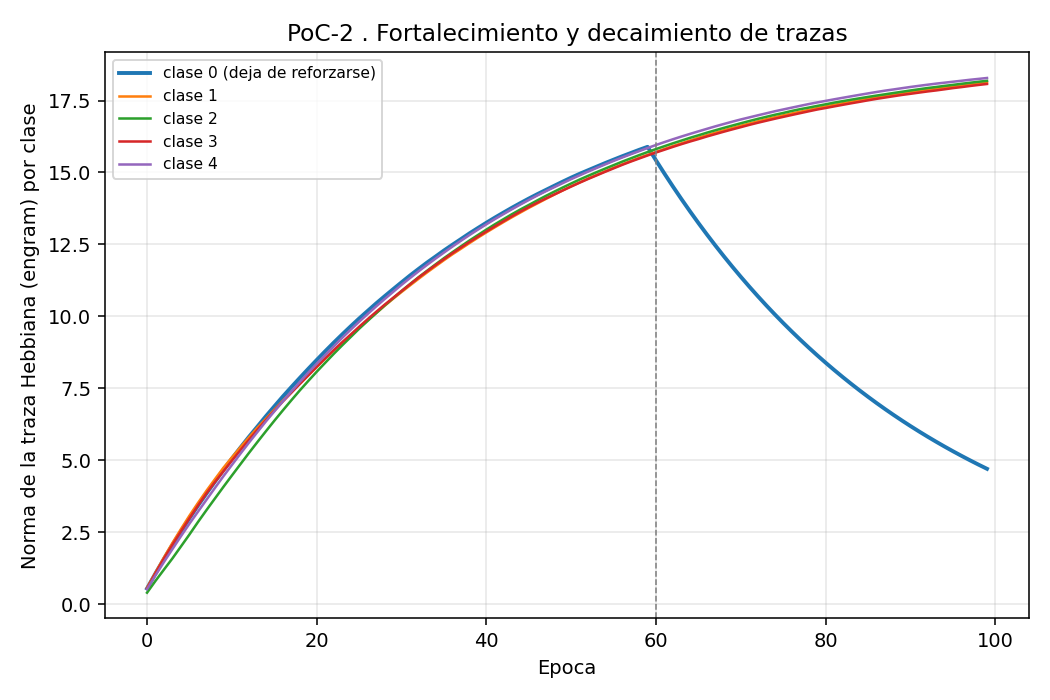

Norma final traza clase 0 (sin refuerzo): 4.700
Norma maxima que alcanzo la clase 0 (fase 1): 15.892
Norma final promedio resto de clases (con refuerzo): 18.168


In [4]:
plt.figure(figsize=(7.5, 5))
for c in range(N_CLASSES):
    label = f"clase {c}" + (" (deja de reforzarse)" if c == 0 else "")
    plt.plot(trace_norms_history[:, c], label=label, linewidth=2 if c == 0 else 1.3)
plt.axvline(EPOCHS_PHASE1, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Epoca")
plt.ylabel("Norma de la traza Hebbiana (engram) por clase")
plt.title("PoC-2 . Fortalecimiento y decaimiento de trazas")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Norma final traza clase 0 (sin refuerzo): {trace_norms_history[-1, 0]:.3f}")
print(
    f"Norma maxima que alcanzo la clase 0 (fase 1): {trace_norms_history[:EPOCHS_PHASE1, 0].max():.3f}"
)
print(
    f"Norma final promedio resto de clases (con refuerzo): {trace_norms_history[-1, 1:].mean():.3f}"
)

**Lectura del resultado:** durante la Fase 1, las 5 trazas crecen juntas y de forma pareja (todas las clases se refuerzan por igual). Al entrar a la Fase 2, la traza de la clase 0 cae de ~15.9 a ~4.7 — una pérdida de casi el 70% de su magnitud — mientras las otras 4 siguen creciendo hasta ~18.2. **Las trazas se fortalecen con la repetición y decaen cuando no se refuerzan**, justo el comportamiento que pedía la Hipótesis 2.

## 5. Conclusión de la PoC-2

Quedan confirmadas las dos propiedades que se buscaban en esta PoC: entrenamiento estable de la memoria Hebbiana junto con el encoder, y la dinámica de fortalecimiento/decaimiento de trazas que se esperaba de la literatura.

Junto con la PoC-1, ya están validados por separado los dos mecanismos centrales de EMBER: recuperación por similitud robusta al ruido (SDM) y memoria entrenable con trazas que se fortalecen y decaen (ENN).

**Próximo paso (PoC-3 / PoC-4):** explorar el circuito spiking con STDP, y luego la combinación Spiking-SDM, antes de llegar a la PoC-5 (el núcleo integrado de EMBER, que combina SDM y ENN con el ciclo de vida completo del engrama: fuerza, edad, utilidad, novedad y error de predicción).